<a href="https://colab.research.google.com/github/huongtiu301027-a11y/NguyenthiHuong/blob/main/Week3%3Bweek4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# =========================
# 1. Nhập dữ liệu
# =========================
x1 = np.array([3,6,9,10,12,15,18,20])
x2 = np.array([0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0])
x3 = np.array([1.0,1.2,1.5,1.8,2.0,2.2,2.5,2.8])
y  = np.array([1.1,2.0,3.2,3.4,3.9,5.0,6.2,6.6])

n = len(y)

# =========================
# 2. Tạo ma trận X (thêm cột 1 cho hệ số chặn)
# =========================
X = np.column_stack((np.ones(n), x1, x2, x3))

# =========================
# 3. Tính hệ số theo công thức OLS
# =========================
w = np.linalg.inv(X.T @ X) @ X.T @ y

w0, w1, w2, w3 = w

# =========================
# 4. Tính RMSE
# =========================
y_pred = X @ w
rmse = np.sqrt(np.mean((y - y_pred)**2))

# =========================
# 5. In kết quả
# =========================
print("\n--- KẾT QUẢ CÂU 3A ---")
print(f"Hệ số chặn (Intercept - w0): {w0}")
print(f"Hệ số w1 (Doanh thu): {w1}")
print(f"Hệ số w2 (MKT): {w2}")
print(f"Hệ số w3 (Lương): {w3}")
print(f"Sai số RMSE: {rmse}")

# =========================
# 6. Dự báo tháng 9
# =========================
thang_9 = np.array([1, 25, 5.0, 3.5])
du_bao_t9 = thang_9 @ w

print(f"\nDự báo lợi nhuận tháng 9: {du_bao_t9}")


--- KẾT QUẢ CÂU 3A ---
Hệ số chặn (Intercept - w0): -0.4849056603805315
Hệ số w1 (Doanh thu): 0.474213836478073
Hệ số w2 (MKT): -1.003773584906634
Hệ số w3 (Lương): 0.6163522012590097
Sai số RMSE: 0.07214154500510288

Dự báo lợi nhuận tháng 9: 8.508805031444657



--- KẾT QUẢ CÂU 3B ---
Intercept (w0): -0.02928176795595472
w1 (Doanh thu): 0.4674033149171547
w2 (MKT): -0.6574585635360211


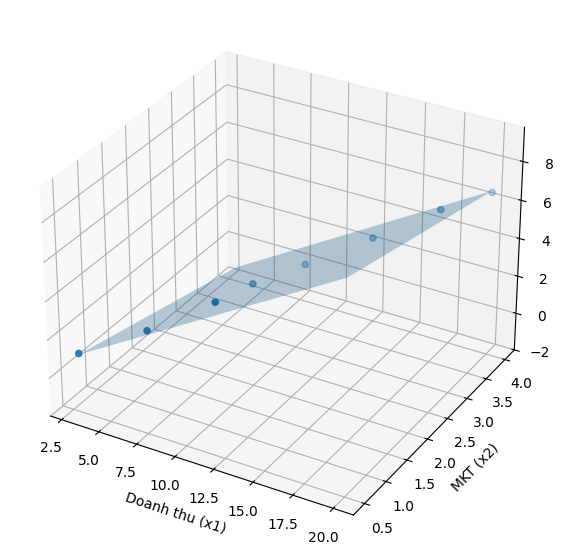

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Nhập dữ liệu
# =========================
x1 = np.array([3,6,9,10,12,15,18,20])
x2 = np.array([0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0])
y  = np.array([1.1,2.0,3.2,3.4,3.9,5.0,6.2,6.6])

n = len(y)

# =========================
# 2. Tạo ma trận X (thêm cột 1)
# =========================
X = np.column_stack((np.ones(n), x1, x2))

# =========================
# 3. Tính hệ số theo OLS
# =========================
w = np.linalg.inv(X.T @ X) @ X.T @ y
w0, w1, w2 = w

print("\n--- KẾT QUẢ CÂU 3B ---")
print("Intercept (w0):", w0)
print("w1 (Doanh thu):", w1)
print("w2 (MKT):", w2)

# =========================
# 4. Vẽ biểu đồ 3D
# =========================
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Vẽ điểm thực tế
ax.scatter(x1, x2, y)

# Tạo lưới mặt phẳng
x1_surf, x2_surf = np.meshgrid(
    np.linspace(min(x1), max(x1), 10),
    np.linspace(min(x2), max(x2), 10)
)

# Tính giá trị dự đoán trên mặt phẳng
y_surf = w0 + w1*x1_surf + w2*x2_surf

# Vẽ mặt phẳng
ax.plot_surface(x1_surf, x2_surf, y_surf, alpha=0.3)

ax.set_xlabel('Doanh thu (x1)')
ax.set_ylabel('MKT (x2)')
ax.set_zlabel('Lợi nhuận (y)')

plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# ======================
# DỮ LIỆU
# ======================
x1 = np.array([3,6,9,10,12,15,18,20]).reshape(-1,1)
x2 = np.array([0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0]).reshape(-1,1)

X = np.hstack((x1, x2))
y = np.array([1.1,2.0,3.2,3.4,3.9,5.0,6.2,6.6])

# ======================
#  MÔ HÌNH BẬC 1
# ======================
model1 = LinearRegression()
model1.fit(X, y)

y_pred1 = model1.predict(X)
rmse1 = np.sqrt(mean_squared_error(y, y_pred1))

print("RMSE bậc 1:", rmse1)

# ======================
#  MÔ HÌNH BẬC 2
# ======================
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model2 = LinearRegression()
model2.fit(X_poly, y)

y_pred2 = model2.predict(X_poly)
rmse2 = np.sqrt(mean_squared_error(y, y_pred2))

print("RMSE bậc 2:", rmse2)

# ======================
# SO SÁNH
# ======================
if rmse2 < rmse1:
    print("=> Mô hình bậc 2 tốt hơn (RMSE nhỏ hơn)")
else:
    print("=> Mô hình bậc 1 tốt hơn")

RMSE bậc 1: 0.07497697620820666
RMSE bậc 2: 0.021158317953104328
=> Mô hình bậc 2 tốt hơn (RMSE nhỏ hơn)


In [ ]:
import numpy as np
import time
from sklearn.linear_model import LinearRegression

# Hàm chạy mô hình và đo thời gian
def run_model(n_features):
    print(f"\n=== Số biến: {n_features} ===")

    # Tạo dữ liệu giả lập
    np.random.seed(42)
    X = np.random.rand(10000, n_features)
    true_coef = np.random.rand(n_features)
    y = X @ true_coef + np.random.randn(10000) * 0.1

    # Đo thời gian
    start = time.time()

    model = LinearRegression()
    model.fit(X, y)

    end = time.time()

    print("Thời gian thực hiện:", round(end - start, 4), "giây")

# Chạy cho 10, 100, 1000 biến
run_model(10)
run_model(100)
run_model(1000)


=== Số biến: 10 ===
Thời gian thực hiện: 0.0412 giây

=== Số biến: 100 ===
Thời gian thực hiện: 0.3434 giây

=== Số biến: 1000 ===
Thời gian thực hiện: 1.6658 giây


6a) Công thức khai triển Taylor

Khai triển Taylor bậc 2 của hàm số f(x) tại điểm x_0:

f(x) \approx f(x_0) + f’(x_0)(x-x_0) + \frac{f’’(x_0)}{2}(x-x_0)^2

Trong hồi quy tuyến tính, ta xấp xỉ hàm mất mát (Loss function) quanh một điểm gần nghiệm để tìm cực tiểu.

Hàm mất mát MSE:

J(\beta) = \frac{1}{n} \sum (y_i - X_i\beta)^2

Taylor giúp ta xấp xỉ hàm này để tìm nghiệm tối ưu.

6b) Tìm nghiệm bằng phương pháp Newton

 Công thức Newton:

\beta_{new} = \beta_{old} - H^{-1} \nabla J(\beta)

Trong đó:
 • \nabla J(\beta) = Gradient
 • H = Hessian matrix

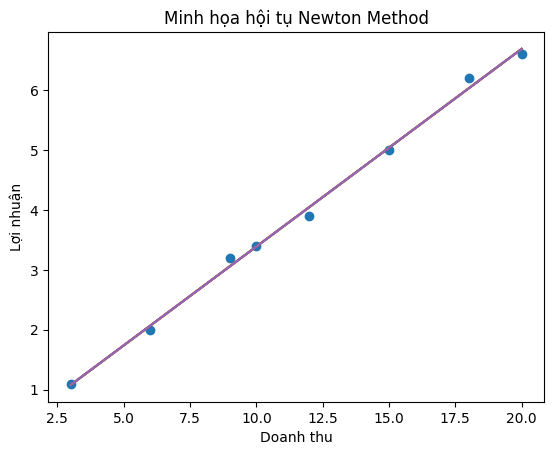

Beta cuối cùng: [0.08991067 0.32990016]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# DỮ LIỆU
# ======================
X_raw = np.array([3,6,9,10,12,15,18,20])
y = np.array([1.1,2.0,3.2,3.4,3.9,5.0,6.2,6.6])

# Thêm cột bias
X = np.column_stack((np.ones(len(X_raw)), X_raw))

# ======================
# NEWTON METHOD
# ======================
beta = np.zeros(2)
betas_history = []

n = len(y)

for i in range(5):  # 5 bước lặp để minh họa
    gradient = -2/n * X.T @ (y - X @ beta)
    hessian = 2/n * X.T @ X

    beta = beta - np.linalg.inv(hessian) @ gradient
    betas_history.append(beta.copy())

# ======================
# VẼ BIỂU ĐỒ MINH HỌA
# ======================
plt.figure()

# Vẽ điểm dữ liệu
plt.scatter(X_raw, y)

# Vẽ các đường hồi quy qua từng bước
x_line = np.linspace(min(X_raw), max(X_raw), 100)

for b in betas_history:
    y_line = b[0] + b[1]*x_line
    plt.plot(x_line, y_line)

plt.title("Minh họa hội tụ Newton Method")
plt.xlabel("Doanh thu")
plt.ylabel("Lợi nhuận")

plt.show()

print("Beta cuối cùng:", beta)

6c) Gradient Descent
 -Công thức toán học

Hàm mất mát MSE:

J(\beta) = \frac{1}{n} \sum (y - X\beta)^2

Gradient của hàm mất mát:

\nabla J(\beta) = -\frac{2}{n} X^T (y - X\beta)

Cập nhật tham số:

\beta = \beta - \alpha \nabla J(\beta)

Trong đó:
 \alpha là learning rate
  lặp cho đến khi hội tụ

- Giải thích ngắn (chứng minh ý tưởng)

Gradient là hướng tăng nhanh nhất của hàm.
Muốn tìm cực tiểu → ta đi ngược hướng gradient.
Vì vậy ta trừ đi \alpha \nabla J(\beta).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# DỮ LIỆU
# ======================
X_raw = np.array([3,6,9,10,12,15,18,20])
y = np.array([1.1,2.0,3.2,3.4,3.9,5.0,6.2,6.6])

# Thêm cột bias
X = np.column_stack((np.ones(len(X_raw)), X_raw))

# ======================
# GRADIENT DESCENT
# ======================
beta = np.zeros(2)
alpha = 0.001
n = len(y)

loss_history = []

for i in range(1000):
    gradient = -2/n * X.T @ (y - X @ beta)
    beta = beta - alpha * gradient

    # Tính loss
    loss = np.mean((y - X @ beta)**2)
    loss_history.append(loss)

print("Beta sau Gradient Descent:", beta)



Beta sau Gradient Descent: [0.04361085 0.33316822]


Trong quá trình thực hiện, em nhận thấy rằng việc lựa chọn bậc của đa thức ảnh hưởng rất lớn đến độ chính xác của mô hình. Khi tăng bậc, RMSE giảm nhưng nguy cơ quá khớp (overfitting) cũng tăng. Ngoài ra, khi kích thước dữ liệu tăng, thời gian xử lý tăng đáng kể, cho thấy tầm quan trọng của tối ưu thuật toán và lựa chọn phương pháp phù hợp như Gradient Descent thay vì công thức ma trận trực tiếp.